In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
def degrade_resolution(img_array, factor):
    h, w = img_array.shape
    small = img_array[::factor, ::factor]
    restored = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

    return restored

def degrade_quantization(img_array, n_levels):
    f = 256 // n_levels
    quantized = (img_array // f) * f
    return quantized

In [3]:
img = cv2 \
    .imread("input_data/Good-Welding-images_22_jpeg_jpg.rf.318c9d57367dca722350fe8d63b44591.jpg", cv2.INTER_NEAREST)

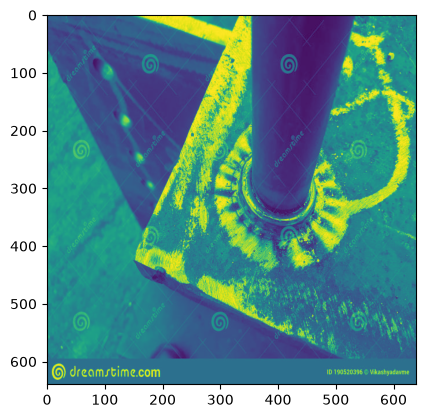

In [4]:
plt.imshow(img)

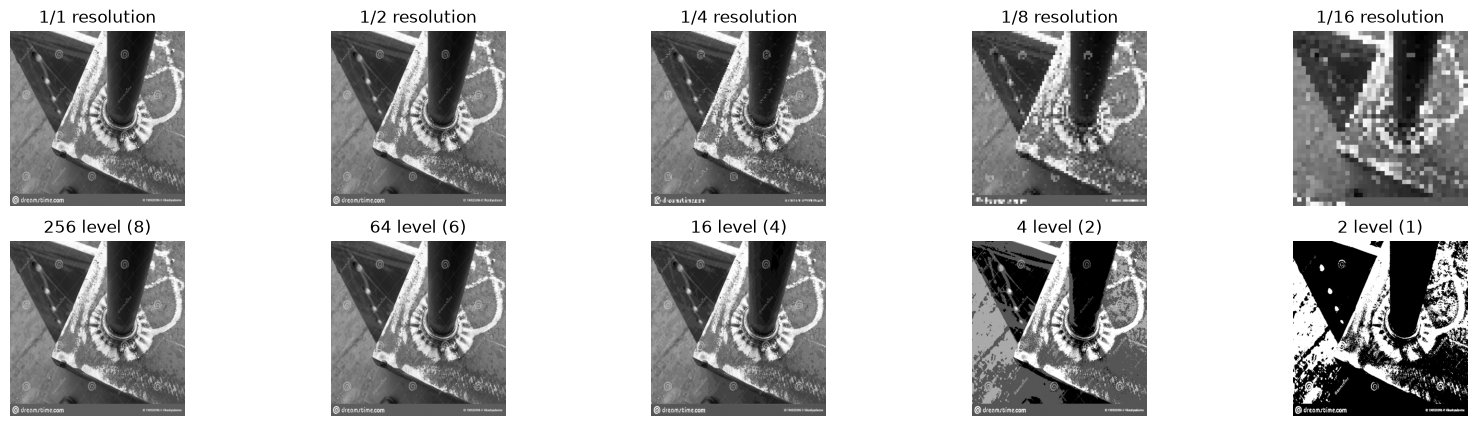

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20,5))

factors  = [1,2,4,8,16]

for i, f in enumerate(factors):
    degrade = degrade_resolution(img, f)

    axes[0][i].imshow(degrade, cmap='gray')
    axes[0][i].axis('off')
    axes[0][i].set_title(f"1/{f} resolution")


n_levels = [256, 64, 16, 4, 2]

for i, level in enumerate(n_levels):

    quatized = degrade_quantization(img, level)

    bits = int(np.log2(level))

    axes[1][i].imshow(quatized, cmap='gray')
    axes[1][i].axis('off')
    axes[1][i].set_title(f"{level} level ({bits})")